In [11]:
import numpy as np
import matplotlib.pyplot as plt
import simpy
import logging

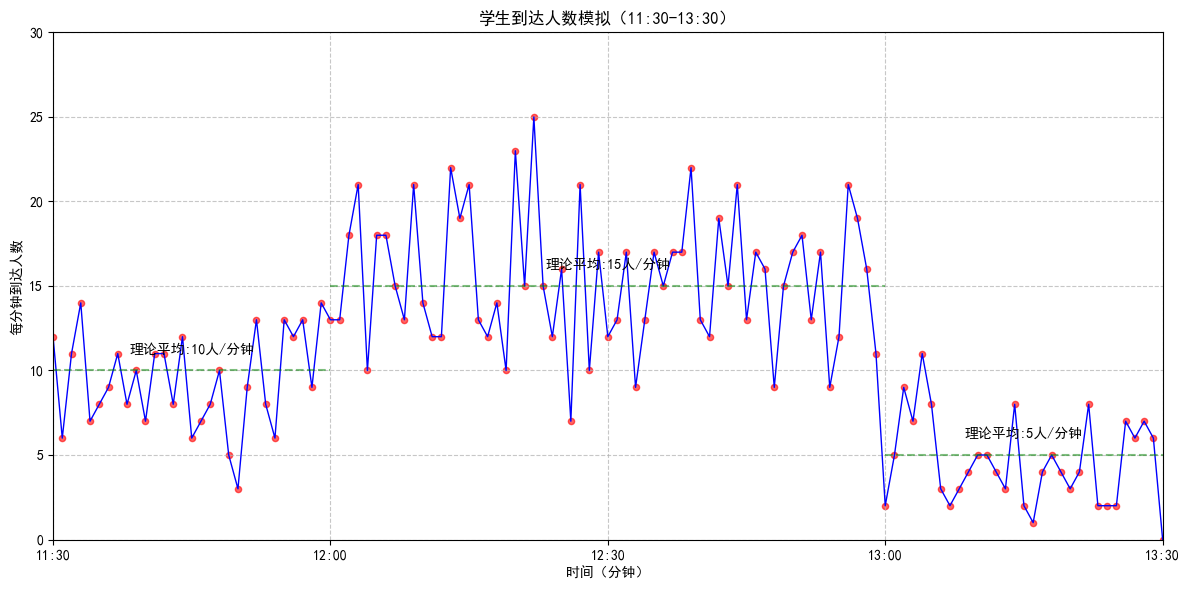

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import logging

# 配置日志，屏蔽字体警告
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# 定义时间段和对应的到达率
time_ranges = [
    (0, 30, 10),    # 11:30-12:00
    (30, 90, 15),   # 12:00-13:00
    (90, 120, 5)    # 13:00-13:30
]

# 模拟每分钟到达的学生人数
np.random.seed(42)
arrivals = []
time_points = list(range(121))  # 0-120分钟

for t in time_points:
    for start, end, rate in time_ranges:
        if start <= t < end:
            arrivals.append(np.random.poisson(rate))
            break
    else:
        arrivals.append(0)  # 不在任何时间段内的情况

# 绘制每分钟到达人数的折线图
plt.figure(figsize=(12, 6))
plt.plot(time_points, arrivals, 'b-', linewidth=1)
plt.scatter(time_points, arrivals, color='red', s=20, alpha=0.6)

# 添加平均到达率的参考线
for start, end, rate in time_ranges:
    plt.hlines(rate, start, end, colors='green', linestyles='dashed', alpha=0.5)
    plt.text((start + end) / 2, rate + 1, f'理论平均:{rate}人/分钟', ha='center')

# 设置图表标题和坐标轴标签
plt.title('学生到达人数模拟（11:30-13:30）')
plt.xlabel('时间（分钟）')
plt.ylabel('每分钟到达人数')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([0, 30, 60, 90, 120], ['11:30', '12:00', '12:30', '13:00', '13:30'])
plt.xlim(0, 120)
plt.ylim(0, max(arrivals) + 5)

plt.tight_layout()
plt.show()


In [13]:
print(arrivals)

[12, 6, 11, 14, 7, 8, 9, 11, 8, 10, 7, 11, 11, 8, 12, 6, 7, 8, 10, 5, 3, 9, 13, 8, 6, 13, 12, 13, 9, 14, 13, 13, 18, 21, 10, 18, 18, 15, 13, 21, 14, 12, 12, 22, 19, 21, 13, 12, 14, 10, 23, 15, 25, 15, 12, 16, 7, 21, 10, 17, 12, 13, 17, 9, 13, 17, 15, 17, 17, 22, 13, 12, 19, 15, 21, 13, 17, 16, 9, 15, 17, 18, 13, 17, 9, 12, 21, 19, 16, 11, 2, 5, 9, 7, 11, 8, 3, 2, 3, 4, 5, 5, 4, 3, 8, 2, 1, 4, 5, 4, 3, 4, 8, 2, 2, 2, 7, 6, 7, 6, 0]


In [14]:
from collections import OrderedDict
import random
total_seconds=120*60  # 7200秒
second_dict=OrderedDict([(second,0) for second in range(total_seconds)])

# 随机分配人数到各秒
for minute in range(120):
    minute_people=arrivals[minute]
    start_second=minute * 60
    
    # 为每个人随机分配秒数（0-59，对应start_second到start_second+59）
    for _ in range(minute_people):
        random_second=random.randint(0, 59)
        total_second=start_second+random_second
        second_dict[total_second]+=1
for i in range(7200,7260):#为了保证全部学生都能取到菜，将食堂开放时间延长一分钟
    second_dict[i]=0

In [15]:
dishes = {
    "快餐": (0.2, 30),
    "面食": (0.3, 48),
    "特色菜": (0.5, 60)
}
max_windows=10#最大窗口数
min_windows=6#最小窗口数
max_queue_length=10#队伍最长存在的人数
special_dish_store=250#特色菜的限制

In [16]:
class Window:
    def __init__(self,OpenOrClose,dishname,sign):
        self.sign=sign#窗口编号，从一开始
        self.open=OpenOrClose
        self.dish=dishname
        self.queue_num=0
        self.queue=[]
        self.iscooking=False
        self.cooktimeleft=0
        self.change_flag=0
        
    def close(self):
        self.open=False
        self.iscooking=False
        self.queue_num=0

    def checkiscooking(self):
        if self.queue_num==0:
            self.iscooking=False
            return False
        return True

    def change(self,openstatus,dishname):
        self.open=openstatus
        self.dish=dishname
        self.change_flag=0

In [17]:
class Student:
    def __init__(self,arrive_time):
        self.arrive_time=arrive_time
        self.over_time=0
        self.chosen_times=0
        self.chosen_dish=None
        self.chosen_window=0
        self.is_angry=False
    

In [18]:
options=["快餐","面食","特色菜"]
weights=[0.2,0.3,0.5]
def choose_window(student,windows_list,students_list):
    choice=random.choices(options,weights=weights,k=1)[0]#按照权重随机选择一个
    student.chosen_dish=choice
    window_signs=[]#提供这个菜品的窗口
    window_queue_num=[]#对应排队人数
    change_flag=0#是否改变选择的标志
    for window in windows_list:
        if window.open==False:#如果没开门不管他
            continue
        if window.dish==choice:#如果提供对应菜品
            window_signs.append(window.sign)#记录对应的窗口号与队列人数
            window_queue_num.append(len(window.queue))
    if len(window_signs)==0:
        change_flag=1
        student.chosen_times+=1
    if len(window_signs)!=0:#如果存在卖他的窗口
        queue_num_min=min(window_queue_num)#找到排队人数最少的窗口号
        sign_min=window_signs[window_queue_num.index(queue_num_min)]
        if queue_num_min<10:#如果最小值小于10，就排这一条
            student.chosen_window=sign_min
            windows_list[sign_min-1].queue.append(student)
            windows_list[sign_min-1].queue_num+=1
        if queue_num_min==10:#如果最小值为10，说明全部排满了
            change_flag=1
            student.chosen_times+=1
            
    if change_flag==1:#如果确实发生了第二次选择
        change_flag=0
        options_tool=["快餐","面食","特色菜"]
        weights_tool=[0.2,0.3,0.5]
        index_tool=options_tool.index(choice)#在剩下的两个菜中选
        del options_tool[index_tool]
        del weights_tool[index_tool]
        choice=random.choices(options_tool,weights=weights_tool,k=1)[0]
        student.chosen_dish=choice
        window_signs=[]#提供这个菜品的窗口
        window_queue_num=[]#对应排队人数
        for window in windows_list:
            if window.open==False:#如果没开门不管他
                continue
            if window.dish==choice:#如果提供对应菜品
                window_signs.append(window.sign)#记录对应的窗口号与队列人数
                window_queue_num.append(len(window.queue))
        if len(window_signs)==0:
            change_flag=2
            student.chosen_times+=1
        if len(window_signs)!=0:#如果存在卖他的窗口
            queue_num_min=min(window_queue_num)#找到排队人数最少的窗口号
            sign_min=window_signs[window_queue_num.index(queue_num_min)]
            if queue_num_min<10:#如果最小值小于10，就排这一条
                student.chosen_window=sign_min
                windows_list[sign_min-1].queue.append(student)
                windows_list[sign_min-1].queue_num+=1
            if queue_num_min==10:#如果最小值为10，说明全部排满了
                change_flag=2
                student.chosen_times+=1
                
    if change_flag==2:#如果发生了第三次选择
        change_flag=0
        index_tool=options_tool.index(choice)#在剩下的两个菜中选
        del options_tool[index_tool]
        del weights_tool[index_tool]
        choice=options_tool[0]
        student.chosen_dish=choice
        window_signs=[]#提供这个菜品的窗口
        window_queue_num=[]#对应排队人数
        for window in windows_list:
            if window.open==False:#如果没开门不管他
                continue
            if window.dish==choice:#如果提供对应菜品
                window_signs.append(window.sign)#记录对应的窗口号与队列人数
                window_queue_num.append(len(window.queue))
        if len(window_signs)==0:
            change_flag=3
            student.chosen_times+=1
        if len(window_signs)!=0:#如果存在卖他的窗口
            queue_num_min=min(window_queue_num)#找到排队人数最少的窗口号
            sign_min=window_signs[window_queue_num.index(queue_num_min)]
            if queue_num_min<10:#如果最小值小于10，就排这一条
                student.chosen_window=sign_min
                windows_list[sign_min-1].queue.append(student)
                windows_list[sign_min-1].queue_num+=1
            if queue_num_min==10:#如果最小值为10，说明全部排满了
                change_flag=3
                student.chosen_times+=1

    if change_flag==3:#如果第三次仍然没有选择
        student.is_angry=True
        students_list.append(student)

In [19]:
windows_set=[
    [(True,"快餐"),(True,"快餐"),(True,"快餐"),(True,"快餐"),(True,"面食"),(True,"面食"),(True,"特色菜"),(True,"特色菜"),(False,""),(False,"")],
    [(True,"快餐"),(True,"快餐"),(True,"快餐"),(True,"快餐"),(True,"面食"),(True,"面食"),(True,"特色菜"),(True,"特色菜"),(True,"快餐"),(True,"特色菜")],
    [(True,"快餐"),(True,"快餐"),(True,"快餐"),(False,""),(True,"面食"),(True,"面食"),(True,"面食"),(False,""),(False,""),(False,"")]]
print(windows_set[0][0][1])

快餐


In [25]:
windows_list=[]#初始化
students_list=[]
for i in range(10):
    window=Window(windows_set[0][i][0],windows_set[0][i][1],i+1)
    windows_list.append(window)
print(windows_list)


import matplotlib
matplotlib.use('QtAgg')
from matplotlib import pyplot as plt
import numpy as np
%matplotlib qt5
x2=[]
y2=[]
plt.ion()
for i in range(7260):
    '''首先更新所有窗口的状态'''
    for window in windows_list:
        if i==1800:
            window.change_flag=1
        if i==5400:
            window.change_flag=2
        if (not window.iscooking):#对于没有在做菜的窗口
             if window.change_flag!=0:#如果到了改菜品的时候
                window.change(windows_set[window.change_flag][window.sign-1][0],windows_set[window.change_flag][window.sign-1][1])#更改的菜品以及窗口开关
                if (window.dish=="特色菜" and special_dish_store==0):#仅针对换菜事件，如果换的是特色菜但是没库存了，关闭窗口
                    window.open=False
                    window.iscooking=False
                    window.queue_num=0
        if window.iscooking:#做菜的窗口,菜的剩余时间-1
            window.cooktimeleft-=1
            if window.cooktimeleft==0:#如果时间剩余0，即完成了菜，那么队列排队人数-1
                student_tool=window.queue.pop(0)
                window.queue_num-=1 
                student_tool.over_time=i#队首的学生记录结束时间
                student_tool.chosen_dish=window.dish#记录最后拿到的菜品是window此时正在卖的菜品
                students_list.append(student_tool)#完成的学生存入另一个列表中用于计算满意度
                
                if window.change_flag!=0:#如果完成后到了改菜品的时候了
                    window.change(windows_set[window.change_flag][window.sign-1][0],windows_set[window.change_flag][window.sign-1][1])#更改的菜品以及窗口开关
                    if (window.dish=="特色菜" and special_dish_store==0):#仅针对换菜事件，如果换的是特色菜但是没库存了，关闭窗口
                        window.open=False
                        window.iscooking=False
                        window.queue_num=0
                    if window.open==False:#如果关窗口了
                        for student in window.queue:#原队列所有人重新选择
                            choose_window(student,windows_list,students_list)
                        window.queue=[]
                        
                if len(window.queue)==0:#检查走后是否还剩下人
                    window.iscooking=False
                else:
                    if window.dish=="特色菜":#检查窗口是否提供特色菜
                       if special_dish_store!=0:#如果是而且库存没空
                           window.cooktimeleft=dishes[window.dish][1]#重置做饭时间
                           special_dish_store-=1#减一份库存
                           if special_dish_store==0:#如果库存空了
                                window.open=False
                                window.iscooking=False
                                window.queue_num=0#关窗口
                           for student in window.queue:
                               choose_window(student,windows_list,students_list)
                           window.queue=[]   
                    if window.dish!="特色菜":#非特色菜
                        window.cooktimeleft=dishes[window.dish][1]#重置做饭时间
    '''再更新新学生'''
    if second_dict[i]==0:
        print(f"第{int(i/60)}分{i%60}秒，有0个学生")
    if second_dict[i]!=0:#如果有新客人来 
        print(f"第{int(i/60)}分{i%60}秒，有{second_dict[i]}个学生")
        for _ in range(second_dict[i]):
            student=Student(i)
            choose_window(student,windows_list,students_list)
            if student.is_angry:
                print("    有一位学生感到愤怒！")
            print(f"    有一位同学去了{student.chosen_window}窗口,选择的菜品是{student.chosen_dish}")
    
        

    x1=[1,2,3,4,5,6,7,8,9,10]
    y1=[]
    for window in windows_list:
        y1.append(len(window.queue))
    plt.subplot(1,2,2)
    plt.clf()  # 清除之前画的图
    plt.bar(x1,y1)  # 画出当前x列表和y列表中的值的图形
    plt.pause(0.001)  # 暂停一段时间，不然画的太快会卡住显示不出来
    for window in windows_list:#针对新上人的窗口
        if window.open:
            if (not window.iscooking and len(window.queue)!=0):
                window.iscooking=True
                if window.dish=="特色菜":#对特色菜窗口
                    if special_dish_store==0:#如果库存为0关门，队伍重新选窗口
                        window.open=False
                        window.iscooking=False
                        window.queue_num=0
                        for j in range(len(window.queue)):
                            choose_window(window.queue[j],windows_list,students_list)
                        window.queue=[]
                    if special_dish_store!=0:
                        special_dish_store-=1
                        window.cooktimeleft=dishes[window.dish][1]#重置做饭时间
                else:
                    window.cooktimeleft=dishes[window.dish][1]#重置做饭时间
    c=0
    for student in students_list:
        if student.is_angry:
            c-=dishes[student.chosen_dish][0]
        else:
            c+=dishes[student.chosen_dish][0]*60/(student.over_time-student.arrive_time)
    x2.append(i)
    y2.append(c)
    

[<__main__.Window object at 0x000001C32575AA20>, <__main__.Window object at 0x000001C3256EB320>, <__main__.Window object at 0x000001C3278E7620>, <__main__.Window object at 0x000001C329F6D5B0>, <__main__.Window object at 0x000001C3256A0E30>, <__main__.Window object at 0x000001C32BCADBB0>, <__main__.Window object at 0x000001C329BD1CD0>, <__main__.Window object at 0x000001C3279ADE50>, <__main__.Window object at 0x000001C32557DAF0>, <__main__.Window object at 0x000001C32B921640>]
第0分0秒，有1个学生
    有一位同学去了7窗口,选择的菜品是特色菜
第0分1秒，有0个学生
第0分2秒，有0个学生
第0分3秒，有0个学生
第0分4秒，有0个学生
第0分5秒，有1个学生
    有一位同学去了1窗口,选择的菜品是快餐
第0分6秒，有0个学生
第0分7秒，有0个学生
第0分8秒，有0个学生
第0分9秒，有0个学生
第0分10秒，有0个学生
第0分11秒，有0个学生
第0分12秒，有0个学生
第0分13秒，有0个学生
第0分14秒，有0个学生
第0分15秒，有0个学生
第0分16秒，有0个学生
第0分17秒，有0个学生
第0分18秒，有0个学生
第0分19秒，有0个学生
第0分20秒，有0个学生
第0分21秒，有0个学生
第0分22秒，有0个学生
第0分23秒，有0个学生
第0分24秒，有0个学生
第0分25秒，有0个学生
第0分26秒，有0个学生
第0分27秒，有0个学生
第0分28秒，有1个学生
    有一位同学去了8窗口,选择的菜品是特色菜
第0分29秒，有0个学生
第0分30秒，有1个学生
    有一位同学去了7窗口,选择的菜品是特色菜
第0分31秒，有0个学生
第0分32秒，有2个学生
 

KeyboardInterrupt: 

In [19]:
c=0
for student in students_list:
    if student.is_angry:
        c-=dishes[student.chosen_dish][0]
    else:
        c+=dishes[student.chosen_dish][0]*60/(student.over_time-student.arrive_time)
print(c)

92.09042486226875
